In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
df = pd.read_csv('/content/drug200.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)          # (200, 6)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())
print("\nTarget variable (Drug) distribution:\n", df['Drug'].value_counts())

Dataset loaded successfully!
Shape: (200, 6)

Columns: ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug']

First 5 rows:
    Age Sex      BP Cholesterol  Na_to_K   Drug
0   23   F    HIGH        HIGH   25.355  DrugY
1   47   M     LOW        HIGH   13.093  drugC
2   47   M     LOW        HIGH   10.114  drugC
3   28   F  NORMAL        HIGH    7.798  drugX
4   61   F     LOW        HIGH   18.043  DrugY

Target variable (Drug) distribution:
 Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


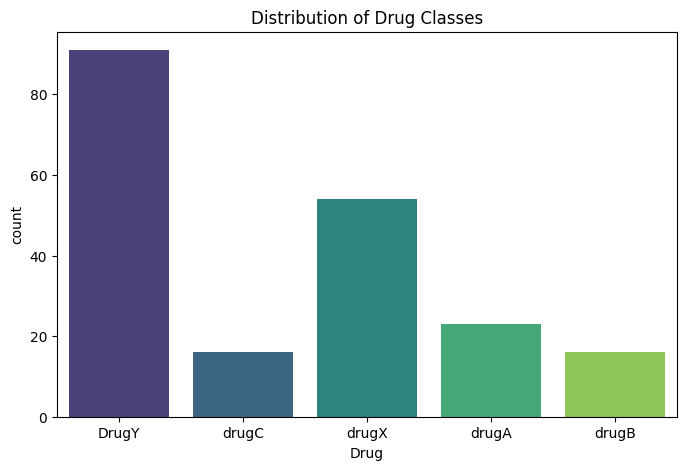

Missing values:
 Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64


In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Drug', palette='viridis')
plt.title('Distribution of Drug Classes')
plt.show()

# Check for missing values
print("Missing values:\n", df.isnull().sum())

In [ ]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['BP'] = le.fit_transform(df['BP'])
df['Cholesterol'] = le.fit_transform(df['Cholesterol'])
df['Drug'] = le.fit_transform(df['Drug'])   # Target encoded

print("Categorical columns encoded!")
print("Unique classes in target:", le.classes_)

Categorical columns encoded!
Unique classes in target: ['DrugY' 'drugA' 'drugB' 'drugC' 'drugX']


In [ ]:
X = df.drop('Drug', axis=1)
y = df['Drug']

# Scale only numerical columns
scaler = StandardScaler()
X[['Age', 'Na_to_K']] = scaler.fit_transform(X[['Age', 'Na_to_K']])

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

print("Preprocessing completed!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Preprocessing completed!
X_train shape: (160, 5)
X_test shape: (40, 5)


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Default KNN model trained!")

Default KNN model trained!


=== Default KNN (k=5) Performance ===
Accuracy: 0.825

Classification Report:

              precision    recall  f1-score   support

       DrugY       0.83      0.83      0.83        18
       drugA       1.00      0.80      0.89         5
       drugB       1.00      0.67      0.80         3
       drugC       1.00      0.33      0.50         3
       drugX       0.73      1.00      0.85        11

    accuracy                           0.82        40
   macro avg       0.91      0.73      0.77        40
weighted avg       0.85      0.82      0.82        40



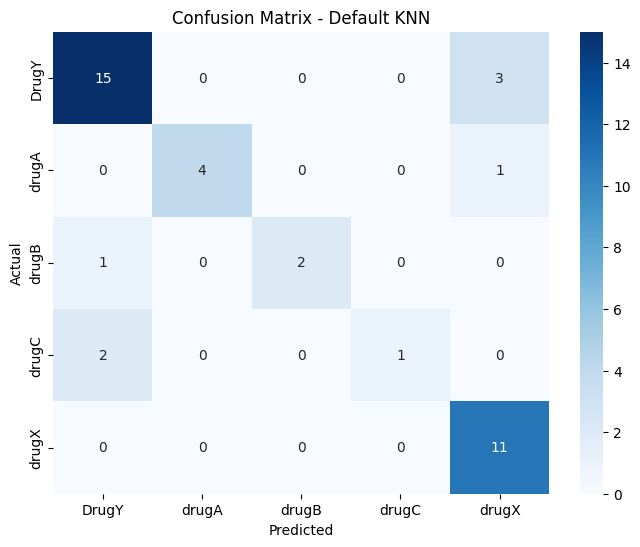

In [ ]:
print("=== Default KNN (k=5) Performance ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Default KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(KNeighborsClassifier(),
                           param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Grid Search completed!")
print("\nBest Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", round(grid_search.best_score_, 4))

Grid Search completed!

Best Hyperparameters: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Best Cross-Validation Accuracy: 0.925


=== Tuned KNN Performance ===
Test Accuracy: 0.9

Classification Report (Tuned):

              precision    recall  f1-score   support

       DrugY       1.00      0.78      0.88        18
       drugA       1.00      1.00      1.00         5
       drugB       1.00      1.00      1.00         3
       drugC       0.75      1.00      0.86         3
       drugX       0.79      1.00      0.88        11

    accuracy                           0.90        40
   macro avg       0.91      0.96      0.92        40
weighted avg       0.92      0.90      0.90        40



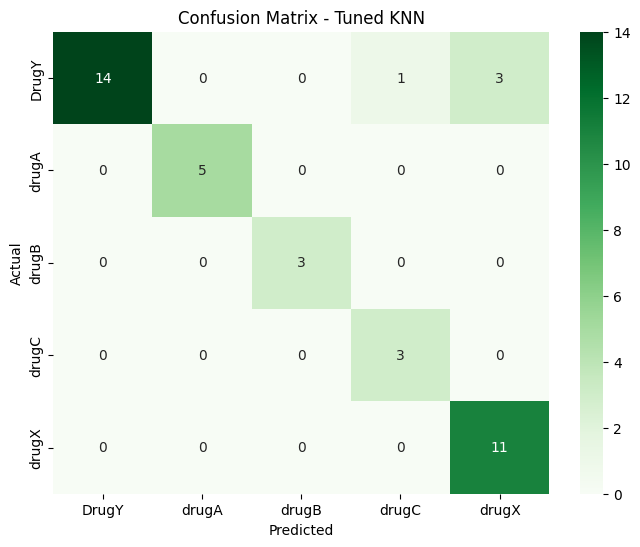

In [ ]:
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test)

print("=== Tuned KNN Performance ===")
print("Test Accuracy:", round(accuracy_score(y_test, y_pred_best), 4))
print("\nClassification Report (Tuned):\n")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# Confusion Matrix for Tuned Model
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8,6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Tuned KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()